# Manuscript figures: triangle signed areas

Two manuscript figures in one notebook.

**Figure 1.** Per-vertex two-triangle signed areas at $p = (x_1, x_2)$, identity vs. bowtie. Visual style mirrors `dvfopt.viz.plot_triangle_debug`: faint reference grid, warped grid overlay in blue, and the two triangles $T^{(1)}_p$, $T^{(2)}_p$ filled by sign category (red = valid, blue = flipped, gray = collapsed).

**Figure 2.** Geometric primitives — what central differences vs. the two-triangle check measure at the bowtie. Central differences operates on the four cardinal neighbours of a pixel (shown two equivalent ways), while the two-triangle check operates on the four corners $q_0, q_1, q_2, q_3$ of the upper-right quad of $p$.

Axes use generic $(x_1, x_2)$ coordinates throughout, matching the manuscript: image-coords origin at the top-left, $x_1$ pointing right and $x_2$ pointing down.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

from dvfopt.jacobian import triangle_sign_areas2D

## Figure 1: per-vertex triangle signed areas at $p = (x_1, x_2)$

- **(a)** Identity deformation: $T_p^\mathrm{L}$ and $T_p^\mathrm{R}$ both have positive signed area (red, valid).
- **(b)** Bowtie deformation: $T_p^\mathrm{L}$ stays valid while $T_p^\mathrm{R}$ flips sign (blue, flipped) — exactly the asymmetric outcome the two-triangle check is designed to catch.

### Helper: per-vertex triangle view (codebase convention)

Reference-grid dots + lines in pale gray, warped-grid lines in blue, and the two triangles $T_p^\mathrm{L}$ and $T_p^\mathrm{R}$ at vertex $p = (x_1, x_2)$ filled by sign category — red = valid, blue = flipped, gray = collapsed.

Following the codebase convention (`dvfopt.jacobian.triangle_sign_det2D`), both triangles have $p$ as a shared vertex and extend BELOW $p$ in image-coords (y-down). They share the vertical edge $p \to (x_1, x_2 + 1)$. The L/R superscript indicates which side of that shared edge each triangle sits on:

- $T_p^\mathrm{L} = (p,\ (x_1 - 1,\, x_2 + 1),\ (x_1,\, x_2 + 1))$ — lower-right half of the cell to the LEFT of $p$ [codebase: `T1`]
- $T_p^\mathrm{R} = (p,\ (x_1,\, x_2 + 1),\ (x_1 + 1,\, x_2))$ — upper-left half of the cell BELOW-RIGHT of $p$ [codebase: `T2`]

The signed-area formula is $\Delta = -\tfrac{1}{2}(AB_x AC_y - AB_y AC_x)$ — the negation accounts for image y-down — giving $+\tfrac{1}{2}$ per triangle on the identity field.

In [2]:
# Codebase convention (dvfopt.jacobian.triangle_sign_det2D): both
# triangles share vertex p and extend BELOW p in image-coords (y-down).
# They share the vertical edge p -> p + (0, +1). The L/R superscript
# refers to which side of that shared edge each triangle sits on:
#
#   T_p^L:  p, p + (-1, +1), p + (0, +1)
#           (lower-right triangle of the cell to the LEFT of p)
#           [codebase: T1]
#   T_p^R:  p, p + (0, +1), p + (+1, 0)
#           (upper-left triangle of the cell BELOW-RIGHT of p)
#           [codebase: T2]
_T1_OFFSETS = [(0, 0), (-1, 1), (0, 1)]   # T_p^L  -- uses left neighbour cell
_T2_OFFSETS = [(0, 0), (0, 1), (1, 0)]    # T_p^R  -- uses right neighbour cell

# Label offsets (data units) used to place T_p^L and T_p^R labels just
# *outside* their triangles. T_p^L is pushed well to the bottom-left
# (toward q_1 / the lower-left corner of the kite) so it visually keys
# to the red triangle's body even when the bowtie reshapes the cell;
# T_p^R goes well above the kite so it clears the phi(p) star label
# (especially important in the identity case where the star sits at p).
_TRI_LABEL_DXDY = [(-0.85, 0.75), (+0.20, -0.85)]


def _signed_area(verts):
    """Codebase signed-area formula: T = -0.5 * (AB.x * AC.y - AB.y * AC.x).

    The negation compensates for image y-down: positive = orientation
    preserved (valid), negative = orientation reversed (fold).
    """
    (Ax, Ay), (Bx, By), (Cx, Cy) = verts
    ABx, ABy = Bx - Ax, By - Ay
    ACx, ACy = Cx - Ax, Cy - Ay
    return -0.5 * (ABx * ACy - ABy * ACx)


def _fill_color(area):
    if area < 0:
        return '#64b5f6'   # blue -- flip
    if area == 0:
        return '#bdbdbd'   # gray -- collapse
    return '#ef5350'       # red -- valid


def _label_color(area):
    """Darker, fully-saturated variant of `_fill_color` for the T_p^L/R
    text labels: same hue family as the triangle fill (so the label
    visually keys to its triangle) but dark enough to remain readable
    on a white background."""
    if area < 0:
        return '#0d47a1'   # blue 900 -- flip
    if area == 0:
        return '#424242'   # grey 800 -- collapse
    return '#b71c1c'       # red 900 -- valid


def draw_axis_compass(ax, loc=(0.05, 0.93), length=0.09, color='#444'):
    """Small in-axes compass showing +x_1 right, +x_2 down. Drawn as a
    single L-shaped line (miter join at the corner) plus two short
    arrowhead annotations at the tips, so the corner closes cleanly with
    no gap and no jut. Coordinates are axes-fraction so the widget is
    independent of data limits and y-axis inversion."""
    x0, y0 = loc
    head = 0.018   # arrowhead-segment length (axes fraction)
    # Continuous L-shape stopping just short of each arrowhead
    ax.plot([x0 + length - head, x0,                  x0],
            [y0,                  y0, y0 - length + head],
            transform=ax.transAxes,
            color=color, lw=1.2,
            solid_joinstyle='miter', solid_capstyle='butt',
            clip_on=False, zorder=10)
    # Arrowhead at the +x_1 tip
    ax.annotate('', xy=(x0 + length, y0),
                xytext=(x0 + length - head, y0),
                xycoords='axes fraction',
                arrowprops=dict(arrowstyle='-|>', color=color, lw=1.2,
                                shrinkA=0, shrinkB=0, mutation_scale=10),
                annotation_clip=False, zorder=10)
    # Arrowhead at the +x_2 tip
    ax.annotate('', xy=(x0, y0 - length),
                xytext=(x0, y0 - length + head),
                xycoords='axes fraction',
                arrowprops=dict(arrowstyle='-|>', color=color, lw=1.2,
                                shrinkA=0, shrinkB=0, mutation_scale=10),
                annotation_clip=False, zorder=10)
    ax.text(x0 + length + 0.012, y0, r'$x_1$',
            transform=ax.transAxes, ha='left', va='center',
            fontsize=9, color=color, zorder=10)
    ax.text(x0, y0 - length - 0.012, r'$x_2$',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=9, color=color, zorder=10)


def plot_pixel_triangles(ax, phi, x, y, radius=2, title='', label_fontsize=13,
                         show_compass=True):
    """Visualize T_p^L and T_p^R at vertex p = (x, y).

    Codebase convention: both triangles share p as a vertex and extend
    BELOW p in image-coords (y-down). They share the vertical edge
    p -- p+(0, +1), with T_p^L on the left and T_p^R on the right.
    """
    dy, dx = phi[0], phi[1]
    H, W = dy.shape

    x0 = max(0, x - radius)
    x1 = min(W - 1, x + radius)
    y0 = max(0, y - radius)
    y1 = min(H - 1, y + radius)

    # Reference grid lines + dots (pale gray background)
    for yi in range(y0, y1 + 1):
        ax.plot([x0, x1], [yi, yi], color='#e8e8e8', lw=0.5, zorder=0)
    for xi in range(x0, x1 + 1):
        ax.plot([xi, xi], [y0, y1], color='#e8e8e8', lw=0.5, zorder=0)
    for yi in range(y0, y1 + 1):
        for xi in range(x0, x1 + 1):
            ax.plot(xi, yi, '.', color='#cfcfcf', markersize=4, zorder=1)

    # Warped grid (blue lines)
    for yi in range(y0, y1 + 1):
        pts = [(xi + dx[yi, xi], yi + dy[yi, xi]) for xi in range(x0, x1 + 1)]
        ax.plot([p[0] for p in pts], [p[1] for p in pts],
                color='#5b7fb5', lw=0.6, zorder=2)
    for xi in range(x0, x1 + 1):
        pts = [(xi + dx[yi, xi], yi + dy[yi, xi]) for yi in range(y0, y1 + 1)]
        ax.plot([p[0] for p in pts], [p[1] for p in pts],
                color='#5b7fb5', lw=0.6, zorder=2)

    # T_p^L, T_p^R triangles. Labels placed *outside* each triangle
    # (down-left of the kite for T_p^L, above for T_p^R) so the text
    # never clips an edge. Label colour matches the triangle's fill hue
    # (darker variant) so the reader visually keys label <-> triangle.
    for i, (offsets, name) in enumerate([(_T1_OFFSETS, r'$T_p^\mathrm{L}$'),
                                          (_T2_OFFSETS, r'$T_p^\mathrm{R}$')]):
        verts = []
        ok = True
        for ox, oy in offsets:
            px, py = x + ox, y + oy
            if not (0 <= px < W and 0 <= py < H):
                ok = False
                break
            verts.append((px + dx[py, px], py + dy[py, px]))
        if not ok:
            continue
        area = _signed_area(verts)
        poly = Polygon(verts, closed=True, facecolor=_fill_color(area),
                       edgecolor='black', lw=1.6, alpha=0.7, zorder=3)
        ax.add_patch(poly)
        dx_off, dy_off = _TRI_LABEL_DXDY[i]
        cx_ = sum(v[0] for v in verts) / 3 + dx_off
        cy_ = sum(v[1] for v in verts) / 3 + dy_off
        ax.text(cx_, cy_, f'{name}\n{area:+.2f}',
                ha='center', va='center', fontsize=label_fontsize, fontweight='bold',
                color=_label_color(area), zorder=4)

    # Mark phi(p) -- the warped position of vertex p = q_0
    cur_x = x + dx[y, x]
    cur_y = y + dy[y, x]
    ax.plot(cur_x, cur_y, '*',
            color='#ffd54f', markeredgecolor='#5d4037',
            markeredgewidth=1.2, markersize=18, zorder=5)
    ax.annotate(r'$\phi(p)$', xy=(cur_x, cur_y),
                xytext=(10, 4), textcoords='offset points',
                fontsize=13, color='#333', fontweight='bold',
                ha='left', va='bottom', zorder=6)

    ax.set_aspect('equal')
    ax.invert_yaxis()   # +x_2 points down (image convention)
    ax.set_xlabel(r'$x_1$', fontsize=12)
    ax.set_ylabel(r'$x_2$', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, fontsize=11)
    if show_compass:
        draw_axis_compass(ax)


### Two deformation fields

Both fields live on a $7 \times 7$ reference grid. The identity field is zero everywhere. The bowtie introduces two equal-and-opposite $x_1$-displacements at horizontally adjacent pixels $p$ and $p + (1, 0)$, causing the warped row through $p$ to fold — the $q_0 \to q_3$ edge of $T_p^\mathrm{R}$ crosses itself.

In [3]:
H = W = 7

# (a) identity
phi_identity = np.zeros((2, H, W))

# (b) bowtie: two opposing x-displacements at adjacent interior pixels
phi_bowtie = np.zeros((2, H, W))
xc, yc = W // 2, H // 2
phi_bowtie[1, yc, xc]     = +1.2  # dx at (x,   y)
phi_bowtie[1, yc, xc + 1] = -1.2  # dx at (x+1, y)

for name, phi in [('identity', phi_identity), ('bowtie', phi_bowtie)]:
    T1, T2 = triangle_sign_areas2D(phi)
    n_neg = int(((T1 <= 0) | (T2 <= 0)).sum())
    print(f'{name:>8s}:  signed-area range [{min(T1.min(), T2.min()):+.3f}, {max(T1.max(), T2.max()):+.3f}]   folded cells: {n_neg}')

identity:  signed-area range [+0.500, +0.500]   folded cells: 0
  bowtie:  signed-area range [-0.700, +1.100]   folded cells: 2


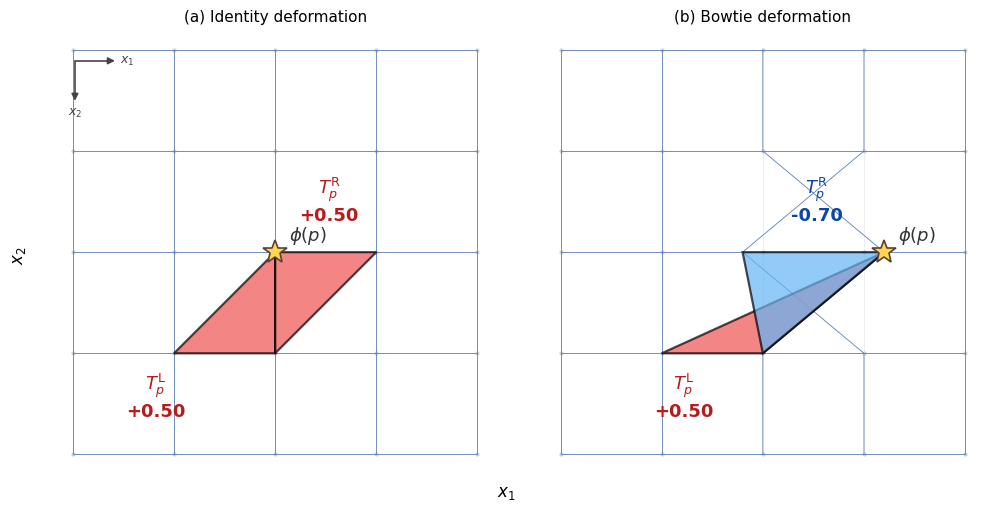

In [4]:
fig1, axes = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')

# Anchor at vertex p = (xc, yc). With the manuscript convention, p's
# upper-right quad has q_0 = (xc, yc) and q_3 = (xc+1, yc) as its bottom
# corners -- exactly the two bowtie pixels -- so T^(2)_p (which contains
# both q_0 and q_3) flips on the bowtie.
plot_pixel_triangles(axes[0], phi_identity, x=xc, y=yc,
                     title='(a) Identity deformation', show_compass=True)
plot_pixel_triangles(axes[1], phi_bowtie,   x=xc, y=yc,
                     title='(b) Bowtie deformation', show_compass=False)

# Show axis labels only once on the whole figure
for ax in axes:
    ax.set_xlabel('')
    ax.set_ylabel('')
fig1.supxlabel(r'$x_1$', fontsize=12)
fig1.supylabel(r'$x_2$', fontsize=12)

plt.show()


## Figure 2: geometric primitives — what each method measures

Panel (a) shows the identity (undeformed) reference grid for context — the cardinal neighbours $p_\mathrm{left}, p_\mathrm{right}, p_\mathrm{up}, p_\mathrm{down}$ of the central pixel $p$ at their pre-deformation positions. Panels (b)–(d) show the warped configuration after applying the bowtie. The shared colormap is the same one used in Figure 1.

- **(a) Identity reference grid.** Cardinal neighbours $p_\mathrm{left}, p_\mathrm{right}, p_\mathrm{up}, p_\mathrm{down}$ and the central pixel at their pre-deformation integer positions.
- **(b) Central differences as a parallelogram of secants.** The central-difference Jacobian of the warp is $J_\phi = I + \nabla u$. Its columns are
  $\;u = (\phi(p_\mathrm{right}) - \phi(p_\mathrm{left}))/2\;$ and $\;v = (\phi(p_\mathrm{down}) - \phi(p_\mathrm{up}))/2$.
  Expanding $\phi(\cdot) = (\cdot) + u(\cdot)$ recovers the diagonal 1's of $I$. The parallelogram with sides $u, v$ is the linearised image of a unit reference cell at $p$, drawn centred on $\phi(p)$ so its centroid sits at the warped pixel position (the star) — reflecting that central differences is a *symmetric* operation averaging over all four cardinal neighbours. Its signed area equals $\det J_\phi = J_\text{CD}$.
- **(c) Central differences as a 4-neighbour diamond.** Equivalently, the diamond formed by the four cardinal neighbours, split horizontally along $p_\mathrm{left} p_\mathrm{right}$ into an upper and a lower triangle. Their summed signed area equals $2\,J_\text{CD}$. The two triangles happen to be equal here because the bowtie is left-right symmetric; for asymmetric warps (e.g. shear) they differ but still sum to $2\,J_\text{CD}$.
- **(d) Two-triangle check (codebase convention).** Both triangles share $p = q_0$ as a vertex and extend BELOW $p$ in image-coords, sharing the vertical edge $\overline{q_0 q_2}$. With $q_0 = p$, $q_1 = p + (-1, +1)$, $q_2 = p + (0, +1)$, $q_3 = p + (+1, 0)$: $T_p^\mathrm{L} = (q_0, q_1, q_2)$ (lower-right half of the cell to the LEFT of $p$) and $T_p^\mathrm{R} = (q_0, q_2, q_3)$ (upper-left half of the cell BELOW-RIGHT of $p$). At the bowtie, $q_3$ swaps to the left of $q_0$, so $T_p^\mathrm{R}$ flips sign — catching the fold that the cardinal-neighbour geometry misses.

### Helpers

In [5]:
def tri_signed_area(A, B, C):
    """Triangle signed area under image y-down convention.

    Positive = orientation preserved. Equivalent to the manuscript's
    +0.5 * (AB.x * AC.y - AB.y * AC.x) under the codebase's vertex
    orderings (which simply use a compensating -0.5 prefactor).
    """
    ABx, ABy = B[0] - A[0], B[1] - A[1]
    ACx, ACy = C[0] - A[0], C[1] - A[1]
    return -0.5 * (ABx * ACy - ABy * ACx)


def draw_faint_warped_grid(ax, phi, color='#dddddd', lw=0.6):
    dy, dx = phi[0], phi[1]
    Hh, Ww = dy.shape
    yy, xx = np.mgrid[:Hh, :Ww]
    gx = xx + dx
    gy = yy + dy
    for i in range(Hh):
        ax.plot(gx[i], gy[i], color=color, lw=lw, zorder=1)
    for j in range(Ww):
        ax.plot(gx[:, j], gy[:, j], color=color, lw=lw, zorder=1)


def style_panel(ax, title, zoom, show_compass=True):
    xlo, xhi, ylo, yhi = zoom
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(yhi, ylo)  # y inverted (image convention): +x_2 points down
    ax.set_aspect('equal')
    ax.set_xlabel(r'$x_1$', fontsize=12)
    ax.set_ylabel(r'$x_2$', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=11)
    if show_compass:
        draw_axis_compass(ax)


### Geometric primitives at the bowtie

Cardinal neighbours, secant vectors, diamond triangles, and the cell's own two triangles.

In [6]:
yy, xx = np.mgrid[:H, :W]
gx_b = xx + phi_bowtie[1]
gy_b = yy + phi_bowtie[0]

# Cardinal neighbours of the bowtie pixel (yc, xc)
P_W = np.array([gx_b[yc, xc - 1], gy_b[yc, xc - 1]])
P_E = np.array([gx_b[yc, xc + 1], gy_b[yc, xc + 1]])
P_N = np.array([gx_b[yc - 1, xc], gy_b[yc - 1, xc]])
P_S = np.array([gx_b[yc + 1, xc], gy_b[yc + 1, xc]])

# Warped position of p itself (the yellow star)
phi_p = np.array([gx_b[yc, xc], gy_b[yc, xc]])

# Secant vectors -- columns of the central-difference Jacobian
# J_phi = I + grad u. The 1's on the diagonal come from differentiating
# x_1 and x_2 themselves: see the manuscript / response.
u = (P_E - P_W) / 2.0
v = (P_S - P_N) / 2.0

# Parallelogram CENTERED at phi(p) (intrinsic local-linearization view):
# best reflects that central differences is a SYMMETRIC operation
# averaging across all four cardinal neighbours -- so phi(p) sits at
# the centroid of the pgram, mirroring how the warped grid is locally
# linearized symmetrically around p. Pgram area = det(J_phi) = J_CD.
anchor = phi_p - (u + v) / 2.0
pgram = [anchor, anchor + u, anchor + u + v, anchor + v]
J_cd = u[0] * v[1] - u[1] * v[0]

# Diamond split along the W–E diagonal
diamond_top = [P_W, P_E, P_N]
diamond_bot = [P_W, P_S, P_E]
diamond_top_area = tri_signed_area(P_W, P_E, P_N)
diamond_bot_area = tri_signed_area(P_W, P_S, P_E)


# Codebase-convention two-triangle check at vertex p = (xc, yc):
# both triangles share p as a vertex and extend BELOW p, sharing the
# vertical edge p -- (xc, yc+1).
#   q_0 = p                       (warped vertex)
#   q_1 = (xc - 1, yc + 1)        (bottom-left of the kite)
#   q_2 = (xc,     yc + 1)        (directly below p, shared)
#   q_3 = (xc + 1, yc)            (right of p, T^(2)'s third vertex)
q0 = np.array([gx_b[yc,     xc],     gy_b[yc,     xc]])      # p   -- bowtie pixel (dx=+1.2)
q1 = np.array([gx_b[yc + 1, xc - 1], gy_b[yc + 1, xc - 1]])  # below-left
q2 = np.array([gx_b[yc + 1, xc],     gy_b[yc + 1, xc]])      # directly below p
q3 = np.array([gx_b[yc,     xc + 1], gy_b[yc,     xc + 1]])  # right of p -- bowtie pixel (dx=-1.2)

T1_p_pts = [q0, q1, q2]   # T^(1)_p -- lower-right half of cell LEFT of p
T2_p_pts = [q0, q2, q3]   # T^(2)_p -- upper-left half of cell BELOW-RIGHT of p


def _delta_codebase(verts):
    """Codebase signed-area formula: Delta = -0.5 * (AB.x AC.y - AB.y AC.x).
    Negation compensates for image y-down convention."""
    A, B, C = verts
    return -0.5 * ((B[0] - A[0]) * (C[1] - A[1])
                   - (B[1] - A[1]) * (C[0] - A[0]))


T1_p_area = _delta_codebase(T1_p_pts)
T2_p_area = _delta_codebase(T2_p_pts)

print(f'(b) parallelogram (sides u, v) centered at phi(p)          signed area = {J_cd:+.3f}   (= J_CD = det J_phi)')
print(f'(c) diamond top / bottom        signed area = {diamond_top_area:+.3f} / {diamond_bot_area:+.3f}   (sum = {diamond_top_area + diamond_bot_area:+.3f} = 2 J_CD)')
print(f'(d) cell triangles  T^(1)_p / T^(2)_p     signed area = {T1_p_area:+.3f} / {T2_p_area:+.3f}')


(b) parallelogram (sides u, v) centered at phi(p)          signed area = +0.400   (= J_CD = det J_phi)
(c) diamond top / bottom        signed area = +0.400 / +0.400   (sum = +0.800 = 2 J_CD)
(d) cell triangles  T^(1)_p / T^(2)_p     signed area = +0.500 / -0.700


### Figure

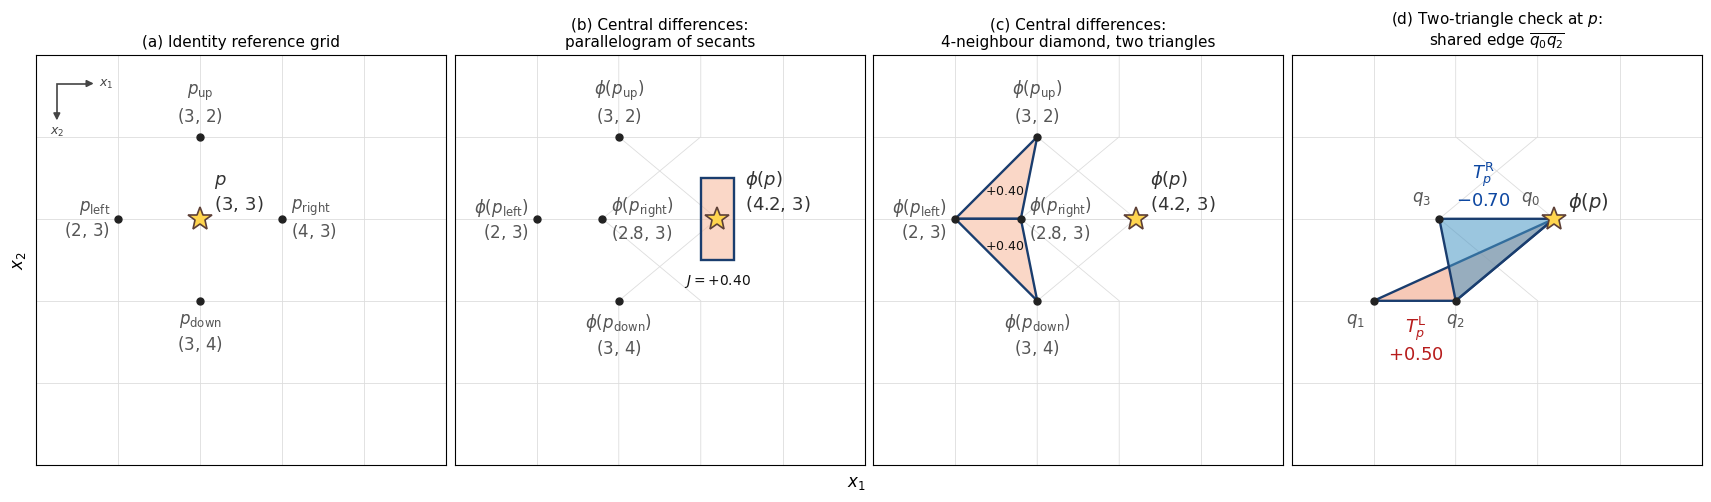

In [7]:
cmap = plt.cm.RdBu_r   # red = positive, blue = negative
vmax2 = 1.2
vmin2 = -vmax2
norm2 = plt.Normalize(vmin2, vmax2)

fig2, axes = plt.subplots(1, 4, figsize=(17, 5.4), layout='constrained')

# Common zoom region around the bowtie. Larger pad gives the cardinal-
# neighbour labels (especially phi(p_left)) room to sit inside the axes
# box, since the labels run along the x_1 axis.
pad = 2.0
zoom = (xc - pad, xc + 1 + pad, yc - pad, yc + 1 + pad)

edge_outline = '#1a3d6e'
neighbour_color = '#222222'
corner_color = '#222222'
current_color = '#ffd54f'   # yellow star for the current point
current_edge = '#5d4037'

text_bbox = dict(facecolor='white', alpha=0.78, edgecolor='none',
                 boxstyle='round,pad=0.18')


def add_label(ax, vertices, text, dx=0, dy=0, show_bbox=True, fontsize=10,
              color='#111'):
    """Place a label at (or offset from) the centroid of `vertices`.
    Pass show_bbox=False to render without the white background -- useful
    when the background would cover an underlying coloured fill. `color`
    can be set to match a triangle's fill so the label visually keys to
    its primitive (used for T_p^L / T_p^R in panel (d))."""
    cx_ = sum(v[0] for v in vertices) / len(vertices) + dx
    cy_ = sum(v[1] for v in vertices) / len(vertices) + dy
    ax.text(cx_, cy_, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color=color,
            bbox=(text_bbox if show_bbox else None), zorder=5)


def label_vertex(ax, point, name, offset=(8, 0), ha='left', va='center',
                 with_coords=True, fontsize=12):
    """Light annotation of a vertex point. If with_coords, places the
    coordinate (x, y) on a second line under the name -- no equals sign,
    the vertical stacking already conveys the labelling."""
    if with_coords:
        text = f'{name}\n$({point[0]:g},\\,{point[1]:g})$'
    else:
        text = name
    ax.annotate(text, xy=(point[0], point[1]),
                xytext=offset, textcoords='offset points',
                fontsize=fontsize, color='#555',
                ha=ha, va=va, zorder=6)


def mark_star(ax, pos, name=r'$\phi(p)$', with_coords=True,
              fontsize=13, color='#333', offset=(10, 4)):
    """Yellow star marker with a name (+ optional coords) label.
    Override `offset` (in display points) to nudge the label position,
    e.g. when the star sits at the centroid of a filled polygon and the
    label should hang off the polygon's right edge instead."""
    ax.plot(pos[0], pos[1], '*',
            color=current_color, markeredgecolor=current_edge,
            markeredgewidth=1.2, markersize=18, zorder=4)
    if with_coords:
        text = f'{name}\n$({pos[0]:g},\\,{pos[1]:g})$'
    else:
        text = name
    ax.annotate(text, xy=(pos[0], pos[1]),
                xytext=offset, textcoords='offset points',
                fontsize=fontsize, color=color, fontweight='bold',
                ha='left', va='bottom', zorder=6)


def add_filled_polygon(ax, vertices, value, fill_alpha=0.55):
    """Polygon with semi-transparent fill and an opaque outline (alpha-blends
    cleanly when triangles intersect at the bowtie)."""
    rgba = cmap(norm2(value))
    fc = (rgba[0], rgba[1], rgba[2], fill_alpha)
    ax.add_patch(Polygon(vertices, closed=True,
                          facecolor=fc,
                          edgecolor=edge_outline, linewidth=1.7, zorder=2))


# Darker, fully-saturated variants of the RdBu_r-ish fill hues; used for
# the T_p^L / T_p^R text labels in panel (d) so each label visually keys
# to its triangle. Same palette as helper-code's _label_color so the two
# figures stay consistent.
def _tri_label_color(area):
    if area < 0:
        return '#0d47a1'   # blue 900 -- flip
    if area == 0:
        return '#424242'   # grey 800 -- collapse
    return '#b71c1c'       # red 900 -- valid


# Cardinal-neighbour label metadata. Reference panel (a) uses bare names;
# deformed panels (b)-(c) wrap each name in phi(.) since the points shown
# are warped positions of those reference neighbours. Lowercase p for the
# neighbours so they match the central pixel name p.
CARDINAL_OFFSETS = [
    ((-6, 0),  'right',  'center'),   # left
    ((6, 0),   'left',   'center'),   # right
    ((0, 8),   'center', 'bottom'),   # up
    ((0, -8),  'center', 'top'),      # down
]
CARDINAL_NAMES_REF = [
    r'$p_\mathrm{left}$',
    r'$p_\mathrm{right}$',
    r'$p_\mathrm{up}$',
    r'$p_\mathrm{down}$',
]
CARDINAL_NAMES_WARPED = [
    r'$\phi(p_\mathrm{left})$',
    r'$\phi(p_\mathrm{right})$',
    r'$\phi(p_\mathrm{up})$',
    r'$\phi(p_\mathrm{down})$',
]


def draw_cardinals(ax, P_list, names=CARDINAL_NAMES_REF):
    for P, name, (off, ha, va) in zip(P_list, names, CARDINAL_OFFSETS):
        ax.plot(P[0], P[1], 'o', color=neighbour_color, markersize=5, zorder=3)
        label_vertex(ax, P, name, offset=off, ha=ha, va=va)


# Identity-grid (undeformed) cardinal neighbours -- for the reference panel
P_W_i = np.array([xc - 1, yc], dtype=float)
P_E_i = np.array([xc + 1, yc], dtype=float)
P_N_i = np.array([xc,     yc - 1], dtype=float)
P_S_i = np.array([xc,     yc + 1], dtype=float)
phi_zero = np.zeros_like(phi_bowtie)


# ----- (a) identity reference grid (before deformation) -----
ax = axes[0]
draw_faint_warped_grid(ax, phi_zero)
draw_cardinals(ax, [P_W_i, P_E_i, P_N_i, P_S_i], names=CARDINAL_NAMES_REF)
mark_star(ax, np.array([xc, yc], dtype=float), name=r'$p$')
style_panel(ax, '(a) Identity reference grid', zoom, show_compass=True)


# ----- (b) parallelogram of secants -----
# Pgram is CENTERED at phi(p): phi(p) sits at the centroid, reflecting
# that central differences is a symmetric operation averaging over all
# four cardinal neighbours. Pgram area = det(J_phi) = J_CD.
ax = axes[1]
draw_faint_warped_grid(ax, phi_bowtie)
add_filled_polygon(ax, pgram, J_cd)
draw_cardinals(ax, [P_W, P_E, P_N, P_S], names=CARDINAL_NAMES_WARPED)
# Push the phi(p) label to the right so it clears the pgram's right
# edge (the star is at the pgram centroid, so the default 10pt nudge
# would land the label over the pgram fill).
mark_star(ax, np.array([gx_b[yc, xc], gy_b[yc, xc]]), offset=(20, 4))
# J label placed just below the parallelogram's bottom edge -- no bbox,
# so it doesn't bleed white into the pgram fill.
pgram_bottom_mid = anchor + 0.5 * u + v
ax.text(pgram_bottom_mid[0], pgram_bottom_mid[1] + 0.15, f'$J = {J_cd:+.2f}$',
        ha='center', va='top', fontsize=10, fontweight='bold',
        color='#111', zorder=5)
style_panel(ax, '(b) Central differences:\nparallelogram of secants', zoom,
            show_compass=False)


# ----- (c) diamond split into two triangles -----
ax = axes[2]
draw_faint_warped_grid(ax, phi_bowtie)
add_filled_polygon(ax, diamond_top, diamond_top_area)
add_filled_polygon(ax, diamond_bot, diamond_bot_area)
draw_cardinals(ax, [P_W, P_E, P_N, P_S], names=CARDINAL_NAMES_WARPED)
mark_star(ax, np.array([gx_b[yc, xc], gy_b[yc, xc]]))
# Diamond triangle area values: no bbox so the coloured fills stay clean,
# and slightly smaller font so the numbers comfortably fit inside the
# (rather narrow) triangle interiors.
add_label(ax, diamond_top, f'${diamond_top_area:+.2f}$',
          show_bbox=False, fontsize=9)
add_label(ax, diamond_bot, f'${diamond_bot_area:+.2f}$',
          show_bbox=False, fontsize=9)
style_panel(ax, '(c) Central differences:\n4-neighbour diamond, two triangles',
            zoom, show_compass=False)


# ----- (d) two-triangle check at the cell (codebase convention) -----
# T_p^L and T_p^R both extend below p; in the bowtie q_0 and q_3
# swap horizontal positions, so the two triangles overlap.
ax = axes[3]
draw_faint_warped_grid(ax, phi_bowtie)
add_filled_polygon(ax, T1_p_pts, T1_p_area)
add_filled_polygon(ax, T2_p_pts, T2_p_area)
for P in (q0, q1, q2, q3):
    ax.plot(P[0], P[1], 'o', color=corner_color, markersize=5, zorder=3)
# q_0 sits at the top of the kite (= warped p, near the star); label upper-left
# so it doesn't collide with the phi(p) label that goes upper-right of the star.
label_vertex(ax, q0, r'$q_0$', offset=(-10, 8), ha='right', va='bottom',
             with_coords=False)
# q_3 is the "right of p" vertex in the reference grid but swaps to the LEFT
# of q_0 in the bowtie warp.
label_vertex(ax, q3, r'$q_3$', offset=(-6, 8), ha='right', va='bottom',
             with_coords=False)
label_vertex(ax, q1, r'$q_1$', offset=(-6, -8), ha='right', va='top',
             with_coords=False)
label_vertex(ax, q2, r'$q_2$', offset=(0, -8), ha='center', va='top',
             with_coords=False)
mark_star(ax, q0, with_coords=False, fontsize=14)
# T_p^L sits well down-and-left of the kite (toward q_1, the lower-left
# corner) so the label clearly keys to the small red triangle even
# though the bowtie warps the cell;  T_p^R sits well above the kite so
# it doesn't collide with phi(p). Label colour matches each triangle's
# fill hue (darker red / blue variant).
add_label(ax, T1_p_pts, f'$T_p^\\mathrm{{L}}$\n${T1_p_area:+.2f}$',
          dx=-0.55, dy=+0.80, show_bbox=False, fontsize=13,
          color=_tri_label_color(T1_p_area))
add_label(ax, T2_p_pts, f'$T_p^\\mathrm{{R}}$\n${T2_p_area:+.2f}$',
          dx=0.0, dy=-0.75, show_bbox=False, fontsize=13,
          color=_tri_label_color(T2_p_area))
style_panel(ax, '(d) Two-triangle check at $p$:\nshared edge $\\overline{q_0 q_2}$',
            zoom, show_compass=False)

# Show axis labels only once on the whole figure
for ax in axes:
    ax.set_xlabel('')
    ax.set_ylabel('')
fig2.supxlabel(r'$x_1$', fontsize=12, y=0.07)
fig2.supylabel(r'$x_2$', fontsize=12)

plt.show()


## Figure 3: Why the diamond's signed area is $2 J_\mathrm{CD}$

A purely geometric explanation of the factor of 2 in panel (c) of Figure 2: the central-difference Jacobian columns $u, v$ are *half*-secants (per-pixel rates), but the diamond's diagonals are *full* secants between cardinal neighbours — twice as long.

- **(a)** The parallelogram with sides $u, v$ has signed area $|u \times v| = J_\mathrm{CD}$. This is exactly the parallelogram of secants from Figure 2(b).
- **(b)** The cardinal-neighbour diamond has diagonals $\vec{d_1} = 2u$ and $\vec{d_2} = 2v$. For *any* quadrilateral the signed area equals $\tfrac{1}{2}|\vec{d_1} \times \vec{d_2}|$, so the diamond's area is $\tfrac{1}{2}|2u \times 2v| = 2J_\mathrm{CD}$. The diamond splits into two triangles along the $p_\mathrm{left} p_\mathrm{right}$ diagonal; each contributes half of the total, so they sum to $2 J_\mathrm{CD}$.

The factor of 2 is therefore a length-scale artefact: doubling each diagonal scales $|\vec{d_1} \times \vec{d_2}|$ by 4, then the $\tfrac{1}{2}$ in the quadrilateral-area formula brings it back down to 2.

Unit vectors $u = (1, 0)$, $v = (0, 1)$ are used here for clarity (so $J_\mathrm{CD} = 1$ and the diamond area is exactly $2$). The same factor-of-2 relationship holds in Figure 2(b)/(c) with $u = (0.4, 0)$, $v = (0, 1)$: parallelogram area $= 0.40$, diamond triangles each $= 0.40$, summing to $0.80 = 2 \cdot 0.40$.

(a) parallelogram |u x v|            = +1.000   (= J_CD)
(b) diamond top / bottom            = +1.000 / +1.000   (sum = +2.000 = 2 J_CD)


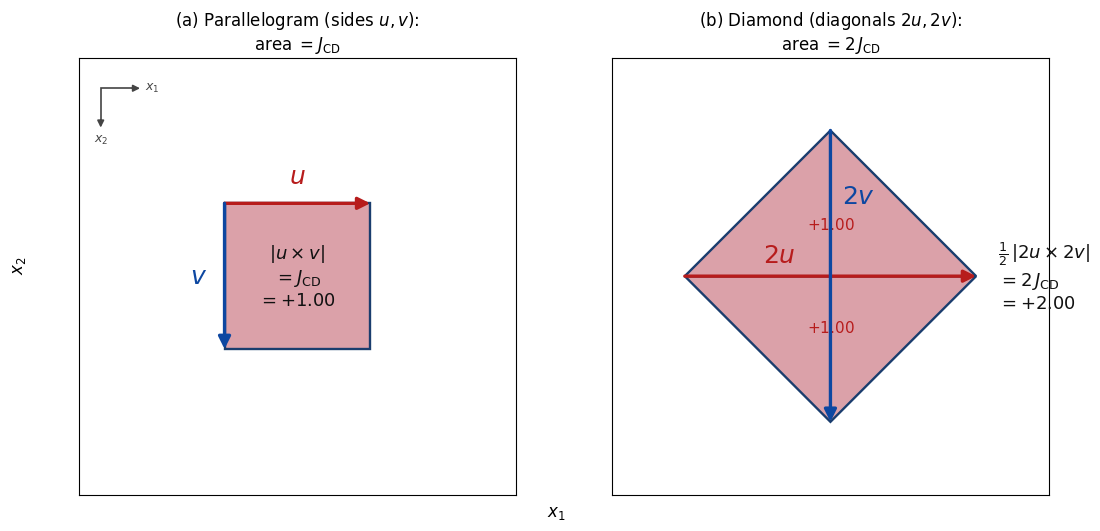

In [8]:
# Figure 3: pure-geometry illustration of the factor-of-2 length-scale
# mismatch between the Jacobian columns (half-secants u, v) and the
# cardinal-neighbour diamond diagonals (full secants 2u, 2v). Use clean
# unit vectors so the numbers come out as 1 and 2 (rather than the
# bowtie's 0.40 and 0.80).
u3 = np.array([1.0, 0.0])
v3 = np.array([0.0, 1.0])
J3 = u3[0] * v3[1] - u3[1] * v3[0]   # = 1.0

c3 = np.array([0.0, 0.0])

fig3, axes3 = plt.subplots(1, 2, figsize=(11, 5.2), layout='constrained')

ax_pad3 = 1.5
zoom3 = (c3[0] - ax_pad3, c3[0] + ax_pad3,
         c3[1] - ax_pad3, c3[1] + ax_pad3)

u_arrow_color = '#b71c1c'   # red, matches "valid" hue
v_arrow_color = '#0d47a1'   # blue


# ----- (a) Parallelogram with sides u, v -----
ax = axes3[0]
anchor3a = c3 - (u3 + v3) / 2.0    # centred on c3 for visual symmetry
pgram3 = [anchor3a, anchor3a + u3, anchor3a + u3 + v3, anchor3a + v3]
add_filled_polygon(ax, pgram3, J3, fill_alpha=0.4)

# u, v arrows from the top-left corner so the columns of J = [u | v]
# emanate from a single point (standard "tangent vectors at base" reading).
arrow_origin = anchor3a
ax.annotate('', xy=arrow_origin + u3, xytext=arrow_origin,
            arrowprops=dict(arrowstyle='-|>', color=u_arrow_color,
                            lw=2.4, shrinkA=0, shrinkB=0, mutation_scale=18),
            zorder=4)
ax.annotate('', xy=arrow_origin + v3, xytext=arrow_origin,
            arrowprops=dict(arrowstyle='-|>', color=v_arrow_color,
                            lw=2.4, shrinkA=0, shrinkB=0, mutation_scale=18),
            zorder=4)
ax.text(arrow_origin[0] + u3[0] / 2, arrow_origin[1] - 0.10, r'$u$',
        fontsize=18, fontweight='bold', color=u_arrow_color,
        ha='center', va='bottom')
ax.text(arrow_origin[0] - 0.12, arrow_origin[1] + v3[1] / 2, r'$v$',
        fontsize=18, fontweight='bold', color=v_arrow_color,
        ha='right', va='center')

pgram_centroid = np.mean(pgram3, axis=0)
ax.text(pgram_centroid[0], pgram_centroid[1],
        f'$|u \\times v|$\n$= J_\\mathrm{{CD}}$\n$= {J3:+.2f}$',
        fontsize=13, ha='center', va='center', fontweight='bold',
        color='#111')

ax.set_xlim(zoom3[:2])
ax.set_ylim(zoom3[3], zoom3[2])    # y inverted (image convention)
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('(a) Parallelogram (sides $u, v$):\narea $= J_\\mathrm{CD}$',
             fontsize=12)
draw_axis_compass(ax)


# ----- (b) Diamond with diagonals 2u, 2v -----
ax = axes3[1]
P_W3 = c3 - u3   # the "p_left" analogue: one half-secant to the left
P_E3 = c3 + u3
P_N3 = c3 - v3
P_S3 = c3 + v3

top_tri3 = [P_W3, P_E3, P_N3]
bot_tri3 = [P_W3, P_S3, P_E3]
top_area3 = tri_signed_area(P_W3, P_E3, P_N3)
bot_area3 = tri_signed_area(P_W3, P_S3, P_E3)
add_filled_polygon(ax, top_tri3, top_area3, fill_alpha=0.4)
add_filled_polygon(ax, bot_tri3, bot_area3, fill_alpha=0.4)

# Per-triangle area labels INSIDE each triangle, smaller font
top_centroid = np.mean(top_tri3, axis=0)
bot_centroid = np.mean(bot_tri3, axis=0)
ax.text(top_centroid[0], top_centroid[1] - 0.02, f'${top_area3:+.2f}$',
        fontsize=11, ha='center', va='center', fontweight='bold',
        color='#b71c1c')
ax.text(bot_centroid[0], bot_centroid[1] + 0.02, f'${bot_area3:+.2f}$',
        fontsize=11, ha='center', va='center', fontweight='bold',
        color='#b71c1c')

# Diagonal arrows: 2u along the W-E diagonal, 2v along the N-S diagonal
ax.annotate('', xy=P_E3, xytext=P_W3,
            arrowprops=dict(arrowstyle='-|>', color=u_arrow_color,
                            lw=2.4, shrinkA=0, shrinkB=0, mutation_scale=18),
            zorder=4)
ax.annotate('', xy=P_S3, xytext=P_N3,
            arrowprops=dict(arrowstyle='-|>', color=v_arrow_color,
                            lw=2.4, shrinkA=0, shrinkB=0, mutation_scale=18),
            zorder=4)
# 2u label: above the W-E arrow (smaller y in y-down = above)
ax.text(c3[0] - 0.35, c3[1] - 0.06, r'$2u$',
        fontsize=18, fontweight='bold', color=u_arrow_color,
        ha='center', va='bottom')
# 2v label: right of the N-S arrow
ax.text(c3[0] + 0.08, c3[1] - 0.55, r'$2v$',
        fontsize=18, fontweight='bold', color=v_arrow_color,
        ha='left', va='center')

# Summary area annotation, outside diamond to the right.
# Matplotlib mathtext doesn't support \tfrac; use \frac{1}{2} instead.
ax.text(c3[0] + 1.15, c3[1],
        f'$\\frac{{1}}{{2}}\\,|2u \\times 2v|$\n$= 2\\,J_\\mathrm{{CD}}$\n$= {top_area3 + bot_area3:+.2f}$',
        fontsize=13, ha='left', va='center', fontweight='bold',
        color='#111')

ax.set_xlim(zoom3[:2])
ax.set_ylim(zoom3[3], zoom3[2])
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('(b) Diamond (diagonals $2u, 2v$):\narea $= 2\\,J_\\mathrm{CD}$',
             fontsize=12)

# Show axis labels only once on the whole figure
for ax in axes3:
    ax.set_xlabel('')
    ax.set_ylabel('')
fig3.supxlabel(r'$x_1$', fontsize=12)
fig3.supylabel(r'$x_2$', fontsize=12)

print(f'(a) parallelogram |u x v|            = {J3:+.3f}   (= J_CD)')
print(f'(b) diamond top / bottom            = {top_area3:+.3f} / {bot_area3:+.3f}'
      f'   (sum = {top_area3 + bot_area3:+.3f} = 2 J_CD)')

plt.show()


## Save figures

Writes PNG and PDF versions of both figures to `./output/` (relative to this notebook).

In [9]:
output_dir = 'output/geometric_primitives'
os.makedirs(output_dir, exist_ok=True)

fig1.savefig(os.path.join(output_dir, 'signed_areas.pdf'), bbox_inches='tight')
fig1.savefig(os.path.join(output_dir, 'signed_areas.png'), dpi=300, bbox_inches='tight')
fig2.savefig(os.path.join(output_dir, 'geometric_primitives.pdf'), bbox_inches='tight')
fig2.savefig(os.path.join(output_dir, 'geometric_primitives.png'), dpi=300, bbox_inches='tight')
fig3.savefig(os.path.join(output_dir, 'diamond_factor_of_two.pdf'), bbox_inches='tight')
fig3.savefig(os.path.join(output_dir, 'diamond_factor_of_two.png'), dpi=300, bbox_inches='tight')

print(f'Saved figures to {os.path.abspath(output_dir)}')

Saved figures to c:\Users\Andy\Documents\GitHub\UCI-iGravi\deformation-field-processing\notebooks\manuscript\output\geometric_primitives
